# Dynamic Anomaly Detection Pipeline



## 1. Imports

In [12]:
import json
from dataclasses import dataclass, field, asdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 50)


## 2. Configurations



In [13]:
@dataclass
class PipelineConfig:
    # --- column names --------------------------------------------------
    id_col: str = "Component_ID"
    lot_col: str = "Batch_ID"
    group_col: str = "Part_Type"
    absolute_result_col: str = "Traditional_Test_Result"
    absolute_fail_value: str = "Fail"
    label_col: str = "Label"

    # --- monitored parameters ------------------------------------------
    params: List[str] = field(default_factory=lambda: ["Leakage", "Resistance", "Vth"])
    early_timepoints: List[str] = field(default_factory=lambda: ["0h", "24h"])

    # --- layer weights (must sum to 1.0) --------------------------------
    weight_lot_relative: float = 0.40
    weight_multivariate: float = 0.40
    weight_drift: float = 0.20

    # --- decision thresholds on the final 0-100 risk score --------------
    threshold_monitor: float = 30.0
    threshold_hold: float = 60.0
    threshold_reject: float = 80.0

    # --- lot-relative (robust z-score) settings -------------------------
    z_score_cap: float = 8.0                      # |z| at/above this maps to full 100

    # --- Isolation Forest hyperparameters -------------------------------
    iforest_n_estimators: int = 300
    iforest_contamination: str = "auto"
    iforest_min_group_size: int = 30              # below this, fall back to the global model
    random_state: int = 42

    def __post_init__(self):
        total = self.weight_lot_relative + self.weight_multivariate + self.weight_drift
        if abs(total - 1.0) > 1e-6:
            raise ValueError(f"Layer weights must sum to 1.0, got {total:.3f}")
        if not (self.threshold_monitor < self.threshold_hold < self.threshold_reject):
            raise ValueError("Thresholds must be strictly increasing")

    def value_col(self, param, timepoint): return f"{param}_{timepoint}"
    def delta_col(self, param): return f"{param}_delta_24h"
    def pct_change_col(self, param): return f"{param}_pct_change_24h"

    def early_value_cols(self):
        return [self.value_col(p, t) for p in self.params for t in self.early_timepoints]

    def lot_relative_cols(self):
        latest = self.early_timepoints[-1]
        return [self.value_col(p, latest) for p in self.params] + [self.delta_col(p) for p in self.params]

    def multivariate_feature_cols(self):
        cols = []
        for p in self.params:
            cols += [self.value_col(p, t) for t in self.early_timepoints]
            cols += [self.delta_col(p), self.pct_change_col(p)]
        return cols

    def required_input_cols(self):
        return [self.id_col, self.lot_col, self.group_col, self.absolute_result_col] + self.early_value_cols()

    def to_dict(self): return asdict(self)


CONFIG = PipelineConfig()
CONFIG


PipelineConfig(id_col='Component_ID', lot_col='Batch_ID', group_col='Part_Type', absolute_result_col='Traditional_Test_Result', absolute_fail_value='Fail', label_col='Label', params=['Leakage', 'Resistance', 'Vth'], early_timepoints=['0h', '24h'], weight_lot_relative=0.4, weight_multivariate=0.4, weight_drift=0.2, threshold_monitor=30.0, threshold_hold=60.0, threshold_reject=80.0, z_score_cap=8.0, iforest_n_estimators=300, iforest_contamination='auto', iforest_min_group_size=30, random_state=42)

## 3. Data loading, validation & imputation


In [14]:
class SchemaError(ValueError):
    pass


def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"Loaded {len(df):,} rows, {len(df.columns)} columns from {path}")
    return df


def validate_schema(df: pd.DataFrame, config: PipelineConfig, require_label: bool = False) -> None:
    required = list(config.required_input_cols())
    if require_label:
        required.append(config.label_col)
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise SchemaError(f"Input data is missing required columns: {missing}")
    n_dupes = df[config.id_col].duplicated().sum()
    if n_dupes:
        print(f"WARNING: {n_dupes} duplicate {config.id_col} values found")


class LotMedianImputer:
    def __init__(self, config: PipelineConfig):
        self.config = config
        self.columns = config.early_value_cols()
        self.group_medians_: Dict[str, dict] = {}
        self.global_medians_: Dict[str, float] = {}
        self._fitted = False

    def fit(self, df: pd.DataFrame) -> "LotMedianImputer":
        lot_col = self.config.lot_col
        for col in self.columns:
            self.group_medians_[col] = df.groupby(lot_col)[col].median().to_dict()
            self.global_medians_[col] = float(df[col].median())
        self._fitted = True
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self._fitted:
            raise RuntimeError("LotMedianImputer must be fit before transform")
        df = df.copy()
        lot_col = self.config.lot_col
        for col in self.columns:
            if df[col].isna().sum() == 0:
                continue
            fallback = df[lot_col].map(self.group_medians_[col]).fillna(self.global_medians_[col])
            df[col] = df[col].fillna(fallback)
        return df

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).transform(df)


## 4. Feature engineering (early-drift features)

In [15]:
def add_drift_features(df: pd.DataFrame, config: PipelineConfig) -> pd.DataFrame:
    df = df.copy()
    first_tp, last_tp = config.early_timepoints[0], config.early_timepoints[-1]
    for p in config.params:
        v_first = df[config.value_col(p, first_tp)]
        v_last = df[config.value_col(p, last_tp)]
        df[config.delta_col(p)] = v_last - v_first
        df[config.pct_change_col(p)] = np.where(v_first != 0, (v_last - v_first) / v_first.abs(), 0.0)
    return df


## 5. Layer 1 - Absolute specification check

In [16]:
class AbsoluteSpecLayer:
    def __init__(self, config: PipelineConfig):
        self.config = config

    def transform(self, df: pd.DataFrame) -> pd.Series:
        col, fail_value = self.config.absolute_result_col, self.config.absolute_fail_value
        return (df[col].astype(str).str.strip().str.lower() == fail_value.lower()).astype(int)


## 6. Layer 2 - Lot-relative robust anomaly score



In [17]:
def _robust_median_mad(series: pd.Series) -> Tuple[float, float]:
    median = float(series.median())
    mad = float((series - median).abs().median()) * 1.4826
    return median, mad


class LotRelativeScorer:
    def __init__(self, config: PipelineConfig):
        self.config = config
        self.columns = config.lot_relative_cols()
        self.group_stats_: Dict[str, Dict] = {}
        self.global_stats_: Dict[str, Tuple[float, float]] = {}
        self._fitted = False

    def fit(self, df: pd.DataFrame) -> "LotRelativeScorer":
        lot_col = self.config.lot_col
        for col in self.columns:
            self.group_stats_[col] = df.groupby(lot_col)[col].apply(_robust_median_mad).to_dict()
            self.global_stats_[col] = _robust_median_mad(df[col])
        self._fitted = True
        print(f"LotRelativeScorer fit on {df[lot_col].nunique()} lots, {len(self.columns)} columns")
        return self

    def transform(self, df: pd.DataFrame) -> Tuple[pd.Series, pd.Series]:
        if not self._fitted:
            raise RuntimeError("LotRelativeScorer must be fit before transform")
        lot_col = self.config.lot_col
        abs_z_frame = pd.DataFrame(index=df.index)
        for col in self.columns:
            medians = df[lot_col].map(lambda lot: self.group_stats_[col].get(lot, (np.nan, np.nan))[0])
            mads = df[lot_col].map(lambda lot: self.group_stats_[col].get(lot, (np.nan, np.nan))[1])
            global_median, global_mad = self.global_stats_[col]
            medians = medians.fillna(global_median)
            mads = mads.fillna(global_mad).replace(0, global_mad if global_mad > 0 else 1e-6)
            abs_z_frame[col] = ((df[col] - medians) / mads).abs()
        worst_z = abs_z_frame.max(axis=1)
        score = (worst_z.clip(upper=self.config.z_score_cap) / self.config.z_score_cap) * 100
        return score, worst_z


## 7. Layer 3 - Multivariate anomaly (Isolation Forest per part type)


In [18]:
GLOBAL_KEY = "__global__"


class MultivariateAnomalyScorer:
    def __init__(self, config: PipelineConfig):
        self.config = config
        self.feature_cols = config.multivariate_feature_cols()
        self.models_: Dict[str, Pipeline] = {}
        self.score_bounds_: Dict[str, Tuple[float, float]] = {}
        self._fitted = False

    def _fit_one(self, X: np.ndarray):
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("iforest", IsolationForest(
                n_estimators=self.config.iforest_n_estimators,
                contamination=self.config.iforest_contamination,
                random_state=self.config.random_state,
            )),
        ])
        pipeline.fit(X)
        raw = -pipeline.decision_function(X)
        p1, p99 = np.percentile(raw, [1, 99])
        return pipeline, (float(p1), float(p99))

    def fit(self, df: pd.DataFrame) -> "MultivariateAnomalyScorer":
        group_col = self.config.group_col
        model, bounds = self._fit_one(df[self.feature_cols].values)
        self.models_[GLOBAL_KEY] = model
        self.score_bounds_[GLOBAL_KEY] = bounds

        for group_value, group_df in df.groupby(group_col):
            if len(group_df) < self.config.iforest_min_group_size:
                print(f"WARNING: group '{group_value}' has only {len(group_df)} rows; using global fallback")
                continue
            model, bounds = self._fit_one(group_df[self.feature_cols].values)
            self.models_[str(group_value)] = model
            self.score_bounds_[str(group_value)] = bounds

        self._fitted = True
        print(f"MultivariateAnomalyScorer fit: {len(self.models_) - 1} group models + 1 global fallback")
        return self

    def transform(self, df: pd.DataFrame) -> pd.Series:
        if not self._fitted:
            raise RuntimeError("MultivariateAnomalyScorer must be fit before transform")
        group_col = self.config.group_col
        scores = pd.Series(index=df.index, dtype=float)
        for group_value, group_df in df.groupby(group_col):
            key = str(group_value) if str(group_value) in self.models_ else GLOBAL_KEY
            model = self.models_[key]
            p1, p99 = self.score_bounds_[key]
            X = group_df[self.feature_cols].values
            raw = -model.decision_function(X)
            norm = np.clip((raw - p1) / (p99 - p1 + 1e-9), 0, 1) * 100
            scores.loc[group_df.index] = norm
        return scores


## 8. Drift scoring + combining all 3 layers into one risk score

In [19]:
class DriftSeverityScorer:
    def __init__(self, config: PipelineConfig):
        self.config = config
        self.bound_: Optional[float] = None

    def _severity(self, df: pd.DataFrame) -> pd.Series:
        cols = [self.config.pct_change_col(p) for p in self.config.params]
        return df[cols].abs().max(axis=1)

    def fit(self, df: pd.DataFrame) -> "DriftSeverityScorer":
        bound = float(self._severity(df).quantile(0.99))
        self.bound_ = bound if bound > 0 else 1e-6
        return self

    def transform(self, df: pd.DataFrame) -> pd.Series:
        if self.bound_ is None:
            raise RuntimeError("DriftSeverityScorer must be fit before transform")
        return (self._severity(df).clip(upper=self.bound_) / self.bound_) * 100


def decide(risk_score: pd.Series, config: PipelineConfig) -> pd.Series:
    bins = [-np.inf, config.threshold_monitor, config.threshold_hold, config.threshold_reject, np.inf]
    labels = ["PASS", "MONITOR", "HOLD", "REJECT"]
    return pd.cut(risk_score, bins=bins, labels=labels, right=False).astype(str)


def combine(lot_score, multivariate_score, drift_score, absolute_fail, config: PipelineConfig) -> pd.Series:
    combined = (
        config.weight_lot_relative * lot_score
        + config.weight_multivariate * multivariate_score
        + config.weight_drift * drift_score
    )
    combined = np.where(absolute_fail == 1, np.maximum(combined, config.threshold_reject + 5), combined)
    combined = np.clip(combined, 0, 100)
    return pd.Series(np.round(combined, 1), index=lot_score.index)


## 9. The pipeline class - `fit` / `predict` / `save` / `load`



In [20]:
MODEL_FILENAME = "pipeline.joblib"
CONFIG_FILENAME = "config.json"
METADATA_FILENAME = "metadata.json"


class AnomalyPipeline:
    def __init__(self, config: Optional[PipelineConfig] = None):
        self.config = config or PipelineConfig()
        self.imputer = LotMedianImputer(self.config)
        self.lot_scorer = LotRelativeScorer(self.config)
        self.mv_scorer = MultivariateAnomalyScorer(self.config)
        self.drift_scorer = DriftSeverityScorer(self.config)
        self.absolute_layer = AbsoluteSpecLayer(self.config)
        self._fitted = False
        self._n_training_rows = None
        self._fitted_at = None

    def fit(self, df: pd.DataFrame) -> "AnomalyPipeline":
        print(f"Fitting pipeline on {len(df):,} rows...")
        validate_schema(df, self.config)
        df = self.imputer.fit_transform(df)
        df = add_drift_features(df, self.config)
        self.lot_scorer.fit(df)
        self.mv_scorer.fit(df)
        self.drift_scorer.fit(df)
        self._fitted = True
        self._n_training_rows = len(df)
        self._fitted_at = datetime.now(timezone.utc).isoformat()
        print("Pipeline fit complete.")
        return self

    def predict(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self._fitted:
            raise RuntimeError("Pipeline must be fit (or loaded) before predict()")
        validate_schema(df, self.config)
        original_index = df.index

        df = self.imputer.transform(df)
        df = add_drift_features(df, self.config)

        absolute_fail = self.absolute_layer.transform(df)
        lot_score, worst_z = self.lot_scorer.transform(df)
        mv_score = self.mv_scorer.transform(df)
        drift_score = self.drift_scorer.transform(df)
        risk_score = combine(lot_score, mv_score, drift_score, absolute_fail, self.config)
        decision = decide(risk_score, self.config)

        result = pd.DataFrame({
            self.config.id_col: df[self.config.id_col],
            self.config.lot_col: df[self.config.lot_col],
            self.config.group_col: df[self.config.group_col],
            "Absolute_Spec_Fail": absolute_fail,
            "Lot_Relative_Score": lot_score.round(1),
            "Worst_Lot_Zscore": worst_z.round(2),
            "Multivariate_Score": mv_score.round(1),
            "Drift_Score": drift_score.round(1),
            "Anomaly_Risk_Score": risk_score,
            "QA_Decision": decision,
        }, index=original_index)

        if self.config.label_col in df.columns:
            result[self.config.label_col] = df[self.config.label_col]
        if self.config.absolute_result_col in df.columns:
            result[self.config.absolute_result_col] = df[self.config.absolute_result_col]
        return result

    def fit_predict(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).predict(df)

    def save(self, dir_path: str) -> None:
        if not self._fitted:
            raise RuntimeError("Cannot save an unfit pipeline")
        path = Path(dir_path)
        path.mkdir(parents=True, exist_ok=True)
        joblib.dump(self, path / MODEL_FILENAME)
        with open(path / CONFIG_FILENAME, "w") as f:
            json.dump(self.config.to_dict(), f, indent=2)
        metadata = {
            "n_training_rows": self._n_training_rows,
            "fitted_at_utc": self._fitted_at,
            "multivariate_groups": list(self.mv_scorer.models_.keys()),
        }
        with open(path / METADATA_FILENAME, "w") as f:
            json.dump(metadata, f, indent=2)
        print(f"Saved pipeline artifacts to {path.resolve()}")

    @classmethod
    def load(cls, dir_path: str) -> "AnomalyPipeline":
        path = Path(dir_path)
        model_path = path / MODEL_FILENAME
        if not model_path.exists():
            raise FileNotFoundError(f"No pipeline artifact found at {model_path}")
        pipeline = joblib.load(model_path)
        print(f"Loaded pipeline from {path.resolve()} (fitted at {pipeline._fitted_at})")
        return pipeline


## 10. Evaluation report

In [21]:
def generate_report(results: pd.DataFrame, config: PipelineConfig) -> str:
    lines = ["=" * 60, "Anomaly Detection - Evaluation Report", "=" * 60]
    lines.append("\nQA Decision breakdown:")
    counts = results["QA_Decision"].value_counts().reindex(["PASS", "MONITOR", "HOLD", "REJECT"]).fillna(0).astype(int)
    for k, v in counts.items():
        lines.append(f"  {k:<10} {v:>6,}  ({v / len(results):.1%})")

    if config.absolute_result_col in results.columns:
        latent = results[
            (results[config.absolute_result_col].astype(str).str.lower() == "pass")
            & (results["QA_Decision"].isin(["HOLD", "REJECT"]))
        ]
        lines.append(f"\nLatent defects caught (passed traditional spec test, flagged HOLD/REJECT): {len(latent):,}")

    if config.label_col in results.columns:
        lines.append("\nCross-check against ground-truth label (validation only):")
        lines.append(pd.crosstab(results["QA_Decision"], results[config.label_col]).to_string())
        fail_mask = results[config.label_col].astype(str).str.lower() == "fail"
        if fail_mask.any():
            caught = results.loc[fail_mask, "QA_Decision"].isin(["HOLD", "REJECT"]).mean()
            lines.append(f"\nRecall on true FAIL components (caught as HOLD/REJECT): {caught:.1%}")
    return "\n".join(lines)


## 11. Run it - fit, save, and score the training data



In [22]:
INPUT_CSV = "burn_in_dataset.csv"
MODEL_DIR = "artifacts/v1"

df = load_csv(INPUT_CSV)
df.head()


Loaded 10,000 rows, 25 columns from burn_in_dataset.csv


,Component_ID,Batch_ID,Part_Type,Part_Family,Proxy_Stress,Stress_Level,Stress_Unit,Timestamp_0h,Timestamp_24h,Timestamp_96h,Timestamp_168h,Leakage_0h,Leakage_24h,Leakage_96h,Leakage_168h,Resistance_0h,Resistance_24h,Resistance_96h,Resistance_168h,Vth_0h,Vth_24h,Vth_96h,Vth_168h,Traditional_Test_Result,Label
0,C501,ISRO-SCL-250421-16,MOSFET,IRF-Series N-Channel,Cycling-Medium,116.0,cycles,2025-04-29 21:00:00,2025-04-30 21:05:50.932379,2025-05-03 20:49:20.717257,2025-05-06 21:04:01.848801,0.905,0.959,0.988,1.047,97.63,98.21,98.28,98.57,1.228,1.230,1.230,1.231,Pass,Safe
1,C502,ISRO-SCL-250224-08,MOSFET,IRF-Series N-Channel,Radiation-Low,26.3,krad,2025-03-13 08:00:00,2025-03-14 08:22:12.865433,2025-03-17 06:48:29.712879,2025-03-20 08:08:24.825653,0.456,0.687,0.935,NaN,104.33,104.95,104.80,105.37,1.309,1.286,1.270,1.273,Pass,Borderline
2,C503,ISRO-SCL-250414-15,Digital Logic IC,74HC-Series Logic Gate,Cycling-Medium,367.0,cycles,2025-05-01 19:00:00,2025-05-02 18:52:26.610561,2025-05-05 19:25:35.193015,2025-05-08 18:44:53.420804,0.895,1.019,1.177,1.269,107.58,107.97,108.21,108.62,1.183,NaN,1.163,1.154,Pass,Safe
3,C504,ISRO-SCL-250113-02,MOSFET,IRF-Series N-Channel,Cycling-Medium,424.0,cycles,2025-01-31 01:00:00,2025-02-01 00:36:38.388221,2025-02-04 01:25:44.237673,2025-02-07 00:25:54.340943,0.151,0.223,0.298,0.377,107.52,108.01,108.41,109.10,1.382,1.380,1.373,1.359,Pass,Borderline
4,C505,ISRO-SCL-250120-03,Op-Amp IC,LM-Series Operational Amplifier,Radiation-Low,44.6,krad,2025-02-07 07:00:00,2025-02-08 07:43:18.286687,2025-02-11 06:50:12.946549,2025-02-14 07:05:55.713333,0.581,0.699,0.910,1.159,92.52,93.47,94.00,94.99,1.168,1.154,1.127,1.125,Fail,Safe


In [23]:
pipeline = AnomalyPipeline(CONFIG)
results = pipeline.fit_predict(df)
pipeline.save(MODEL_DIR)
results.head()

Fitting pipeline on 10,000 rows...
LotRelativeScorer fit on 20 lots, 6 columns
MultivariateAnomalyScorer fit: 4 group models + 1 global fallback
Pipeline fit complete.
Saved pipeline artifacts to /content/artifacts/v1


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result
0,C501,ISRO-SCL-250421-16,MOSFET,0,12.6,1.01,9.8,3.1,9.6,PASS,Safe,Pass
1,C502,ISRO-SCL-250224-08,MOSFET,0,21.0,1.68,8.0,26.1,16.8,PASS,Borderline,Pass
2,C503,ISRO-SCL-250414-15,Digital Logic IC,0,100.0,9.02,38.6,7.1,56.8,MONITOR,Safe,Pass
3,C504,ISRO-SCL-250113-02,MOSFET,0,16.5,1.32,21.6,24.5,20.1,PASS,Borderline,Pass
4,C505,ISRO-SCL-250120-03,Op-Amp IC,1,14.1,1.13,15.2,10.4,85.0,REJECT,Safe,Fail


In [24]:
results.to_csv('anomaly_results.csv', index=False)

In [25]:
print(generate_report(results, CONFIG))

Anomaly Detection - Evaluation Report

QA Decision breakdown:
  PASS        7,115  (71.2%)
  MONITOR       811  (8.1%)
  HOLD          108  (1.1%)
  REJECT      1,966  (19.7%)

Latent defects caught (passed traditional spec test, flagged HOLD/REJECT): 218

Cross-check against ground-truth label (validation only):
Label        Borderline  Fail  Safe
QA_Decision                        
HOLD                 19    40    49
MONITOR             241   394   176
PASS               1323   405  5387
REJECT              256   845   865

Recall on true FAIL components (caught as HOLD/REJECT): 52.6%


## 12. Visualize the results

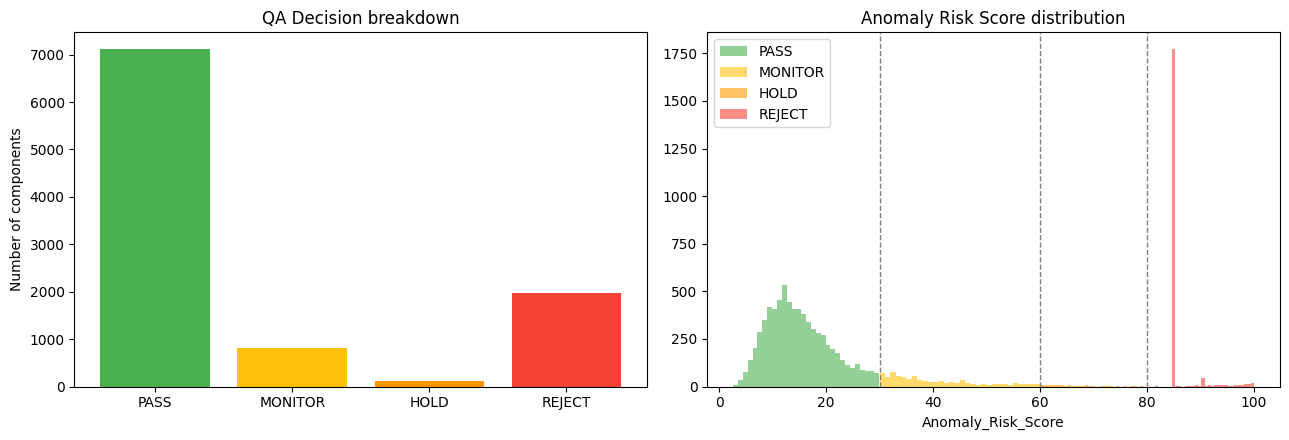

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = ["PASS", "MONITOR", "HOLD", "REJECT"]
colors = {"PASS": "#4CAF50", "MONITOR": "#FFC107", "HOLD": "#FF9800", "REJECT": "#F44336"}
counts = results["QA_Decision"].value_counts().reindex(order)
axes[0].bar(counts.index, counts.values, color=[colors[k] for k in order])
axes[0].set_title("QA Decision breakdown")
axes[0].set_ylabel("Number of components")

for decision in order:
    subset = results[results["QA_Decision"] == decision]
    axes[1].hist(subset["Anomaly_Risk_Score"], bins=30, alpha=0.6, label=decision, color=colors[decision])
axes[1].axvline(CONFIG.threshold_monitor, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(CONFIG.threshold_hold, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(CONFIG.threshold_reject, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Anomaly Risk Score distribution")
axes[1].set_xlabel("Anomaly_Risk_Score")
axes[1].legend()

plt.tight_layout()
plt.show()


In [28]:
latent = results[
    (results[CONFIG.absolute_result_col].astype(str).str.lower() == "pass")
    & (results["QA_Decision"].isin(["HOLD", "REJECT"]))
]
print(f"{len(latent)} components passed the traditional spec test but were flagged HOLD/REJECT.")
latent.sort_values("Anomaly_Risk_Score", ascending=False).head(10)


218 components passed the traditional spec test but were flagged HOLD/REJECT.


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result
3123,C3624,ISRO-SCL-250407-14,MOSFET,0,100.0,11.80,100.0,100.0,100.0,REJECT,Fail,Pass
2202,C2703,ISRO-SCL-250414-15,Digital Logic IC,0,100.0,11.14,100.0,100.0,100.0,REJECT,Fail,Pass
3066,C3567,ISRO-SCL-250106-01,MOSFET,0,100.0,139.39,100.0,100.0,100.0,REJECT,Safe,Pass
8059,C8560,ISRO-SCL-250310-10,Voltage Regulator IC,0,100.0,231.24,100.0,99.8,100.0,REJECT,Safe,Pass
7968,C8469,ISRO-SCL-250224-08,MOSFET,0,100.0,235.40,100.0,98.1,99.6,REJECT,Safe,Pass
513,C1014,ISRO-SCL-250224-08,MOSFET,0,100.0,237.08,100.0,97.5,99.5,REJECT,Safe,Pass
3941,C4442,ISRO-SCL-250407-14,MOSFET,0,100.0,157.76,100.0,97.4,99.5,REJECT,Fail,Pass
5045,C5546,ISRO-SCL-250317-11,Voltage Regulator IC,0,100.0,158.66,100.0,97.0,99.4,REJECT,Borderline,Pass
1673,C2174,ISRO-SCL-250407-14,MOSFET,0,100.0,158.43,100.0,97.0,99.4,REJECT,Safe,Pass
5013,C5514,ISRO-SCL-250113-02,MOSFET,0,100.0,238.88,100.0,96.9,99.4,REJECT,Borderline,Pass


## 13. Reuse: load the saved pipeline and score *new* data



In [29]:
new_batch = df.sample(20, random_state=7)

reloaded_pipeline = AnomalyPipeline.load(MODEL_DIR)
new_results = reloaded_pipeline.predict(new_batch)
new_results


Loaded pipeline from /content/artifacts/v1 (fitted at 2026-09-09T11:59:41.816754+00:00)


,Component_ID,Batch_ID,Part_Type,Absolute_Spec_Fail,Lot_Relative_Score,Worst_Lot_Zscore,Multivariate_Score,Drift_Score,Anomaly_Risk_Score,QA_Decision,Label,Traditional_Test_Result
1977,C2478,ISRO-SCL-250331-13,Voltage Regulator IC,0,20.5,1.64,5.9,13.3,13.2,PASS,Borderline,Pass
3880,C4381,ISRO-SCL-250217-07,Op-Amp IC,0,5.6,0.45,0.2,6.4,3.6,PASS,Safe,Pass
52,C553,ISRO-SCL-250317-11,Voltage Regulator IC,0,10.3,0.82,5.5,9.0,8.1,PASS,Safe,Pass
2551,C3052,ISRO-SCL-250127-04,Op-Amp IC,0,14.1,1.13,23.9,21.1,19.4,PASS,Fail,Pass
2246,C2747,ISRO-SCL-250421-16,MOSFET,1,17.9,1.43,22.4,4.6,85.0,REJECT,Safe,Fail
270,C771,ISRO-SCL-250428-17,Voltage Regulator IC,0,15.7,1.25,3.9,20.4,11.9,PASS,Safe,Pass
601,C1102,ISRO-SCL-250407-14,MOSFET,1,13.6,1.09,16.7,16.7,85.0,REJECT,Safe,Fail
2441,C2942,ISRO-SCL-250127-04,Op-Amp IC,0,9.0,0.72,3.1,9.8,6.8,PASS,Safe,Pass
3286,C3787,ISRO-SCL-250331-13,Voltage Regulator IC,0,15.2,1.22,6.3,19.2,12.4,PASS,Safe,Pass
2967,C3468,ISRO-SCL-250210-06,MOSFET,1,17.1,1.37,37.9,5.1,85.0,REJECT,Fail,Fail
